Первые строки датасета:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proli

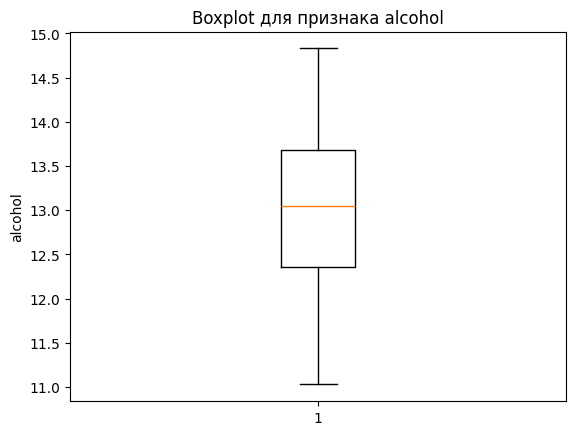


Масштабированный признак:
   alcohol  alcohol_scaled
0    14.23        1.518613
1    13.20        0.246290
2    13.16        0.196879
3    14.37        1.691550
4    13.24        0.295700

Label Encoding:
  alcohol_category  alcohol_category_le
0             high                    0
1           medium                    2
2           medium                    2
3             high                    0
4           medium                    2

One-Hot Encoding:
   alcohol_category_high  alcohol_category_low  alcohol_category_medium
0                    1.0                   0.0                      0.0
1                    0.0                   0.0                      1.0
2                    0.0                   0.0                      1.0
3                    1.0                   0.0                      0.0
4                    0.0                   0.0                      1.0

Итоговый датасет:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14

In [8]:
# =========================================
# Рубежный контроль №1
# Тема: Разведочный анализ и обработка данных
# Датасет: load_wine
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

data = load_wine(as_frame=True)
df = data.frame

print("Первые строки датасета:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика:")
print(df.describe())

df['alcohol_category'] = pd.cut(
    df['alcohol'],
    bins=3,
    labels=['low', 'medium', 'high']
)

print("\nКатегориальный признак:")
print(df[['alcohol', 'alcohol_category']].head())


df.loc[df.sample(frac=0.05).index, 'magnesium'] = np.nan

print("\nКоличество пропусков:")
print(df.isnull().sum())

df['magnesium'] = df['magnesium'].fillna(df['magnesium'].mean())

print("\nПосле обработки пропусков:")
print(df.isnull().sum())

plt.figure()
plt.boxplot(df['alcohol'])
plt.title('Boxplot для признака alcohol')
plt.ylabel('alcohol')
plt.show()

scaler = StandardScaler()
df['alcohol_scaled'] = scaler.fit_transform(df[['alcohol']])

print("\nМасштабированный признак:")
print(df[['alcohol', 'alcohol_scaled']].head())

le = LabelEncoder()
df['alcohol_category_le'] = le.fit_transform(df['alcohol_category'])

print("\nLabel Encoding:")
print(df[['alcohol_category', 'alcohol_category_le']].head())

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[['alcohol_category']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['alcohol_category'])
)

df = pd.concat([df, encoded_df], axis=1)

print("\nOne-Hot Encoding:")
print(encoded_df.head())

print("\nИтоговый датасет:")
print(df.head())

